# Part 4: Model Training and Evaluation
This notebook builds the machine learning models, benchmarks estimators, analyzes feature importances, and saves the production pipeline model.


In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score, confusion_matrix, 
    classification_report, roc_auc_score
)

df = pd.read_csv('processed_telco_churn.csv')



# Train-Test Split & Scaling

In [117]:

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Baseline Model (Logistic Regression)

In [118]:

log_model = LogisticRegression(max_iter=1000)
log_model = LogisticRegression(
    random_state=42
)

log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]


log_model=LogisticRegression(random_state=42,max_iter=1000)







# Baseline Model Evaluation

Baseline Accuracy: 0.8084
Baseline ROC-AUC: 0.8467

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



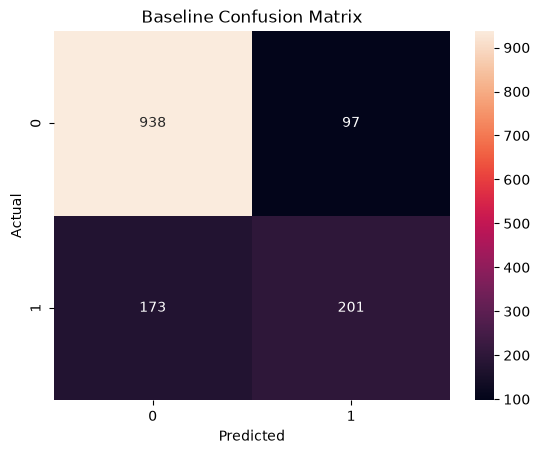

In [119]:

print(f'Baseline Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Baseline ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Baseline Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



# Model Comparison Spot-Check

In [120]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

print('--- Spot-Checking Multi-Model Accuracy ---')
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    print(f'{name}: {acc:.4f}')


--- Spot-Checking Multi-Model Accuracy ---
Logistic Regression: 0.8084
Decision Tree: 0.7339
Random Forest: 0.7850
KNN: 0.7502
Naive Bayes: 0.6494


In [121]:
rf = RandomForestClassifier(
    # n_estimators=300,
    # max_depth=10,
    # min_samples_split=15,
    # min_samples_leaf=2,
    # max_features='sqrt',
    # # class_weight='balanced',
    #  random_state=42
     n_estimators=300, min_samples_split= 5, min_samples_leaf=4, max_features='log2',max_depth=10, bootstrap= True,class_weight='balanced',random_state=42
)


Average Recall: 0.7772575250836121
Test Accuracy: 75.94038325053229
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409


ROC AUC Score
0.8436655558138935


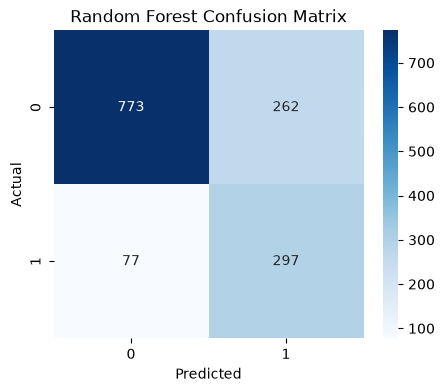

In [122]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

print("Average Recall:", score.mean())

# Train on full training data
rf.fit(X_train, y_train)


# Accuracy on test set
print("Test Accuracy:", rf.score(X_test, y_test) * 100)

# Predictions
pred = rf.predict(X_test)
prob=rf.predict_proba(X_test)[:,1]

# Classification Report
print(classification_report(y_test, pred))
print("\nROC AUC Score")
print(roc_auc_score(y_test, prob))

# Confusion Matrix
cm = confusion_matrix(y_test, pred)


plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# Save the Production Model

In [123]:


joblib.dump(rf, 'customer_churn_model.pkl')
print("Production model successfully saved to 'customer_churn_model.pkl'")


Production model successfully saved to 'customer_churn_model.pkl'
